<a href="https://colab.research.google.com/github/Emanyueruu/Ecoli-Predictive-Sensor-Validation/blob/main/XGBoost_AdaBoost_Validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 5.1 MB/s eta 0:00:00


In [61]:
import pandas as pd

file_path = '/content/vaalkop_utf8.csv'
df = pd.read_csv(file_path)

print("Original Columns:", df.columns.tolist())

raw_columns_to_keep = [
    'pH',
    'Conductivity',
    'Chloride',
    'Turbidity',
    'Nitrates',
    'Chlorophyll',
    'E. coli'
]

df_clean = df[raw_columns_to_keep].copy()
df_clean = df_clean.dropna()

# The baseline strictly used 80 samples. If we have more, we randomly sample 80 to match.
if len(df_clean) > 80:
    df_clean = df_clean.sample(n=80, random_state=42)

print(f"\nCleaned dataset shape: {df_clean.shape}")

# Standardized column names
df_clean.columns = [
    'pH',
    'Conductivity',
    'Chloride',
    'Turbidity',
    'Nitrates ',
    'Chlorophyll',
    'E_coli_Concentration'
]

df_clean.to_csv('vaalkop_clean_set_A.csv', index=False)
print("\nSuccess! Saved as 'vaalkop_clean_set_A.csv'.")
df_clean.head()

Original Columns: ['Unnamed: 0', 'pH', 'Conductivity', 'Chloride', 'Sodium', 'Potassium', 'Hardness', 'Alkalinity, Tot.', 'Prec. Potential*', 'Turbidity', 'Colour', 'Total coliform', 'E. coli', 'Organic Carbon, Diss.', 'Chlorophyll', 'Nitrites', 'Ammonium', 'Nitrates', 'Phosphate', 'Iron', 'Manganese', 'Sulphate']

Cleaned dataset shape: (80, 7) (You want 80 rows, 7 columns)

Success! Saved as 'vaalkop_clean_set_A.csv'.


,pH,Conductivity,Chloride,Turbidity,Nitrates,Chlorophyll,E_coli_Concentration
75,8.41,54,55,5.97,0.3,38,8
1,8.13,49.4,44.8,5,2.21,3.06,64
60,8.79,62.15,65.88,28.25,0.64,59.97,5
23,7.17,65.64,75.4,9.78,1.49,13.77,67
13,8.87,65.47,86.4,6.01,2.1,5.73,7


In [62]:
import pandas as pd

file_path = '/content/vaalkop_utf8.csv'
df = pd.read_csv(file_path)
print("Original Columns:", df.columns.tolist())

raw_columns_to_keep = [
    'pH',
    'Ammonium',
    'Chloride',
    'Nitrites',
    'Iron',
    'Manganese',
    'Phosphate',
    'Sulphate',
    'E. coli'
]

df_clean = df[raw_columns_to_keep].copy()
for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Drop any rows with missing values (NaN) to match the baseline's cleaned criteria
df_clean = df_clean.dropna()

# The baseline strictly used 80 samples.
if len(df_clean) > 80:
    df_clean = df_clean.sample(n=80, random_state=42)

# Note: Set B has 8 features + 1 target = 9 columns
print(f"\nCleaned dataset shape: {df_clean.shape}")

# Standardized column names
df_clean.columns = [
    'pH',
    'Ammonium',
    'Chloride',
    'Nitrites',
    'Iron',
    'Manganese',
    'Phosphate',
    'Sulphate',
    'E_coli_Concentration'
]

df_clean.to_csv('vaalkop_clean_set_B.csv', index=False)
print("\nSuccess! Saved as 'vaalkop_clean_set_B.csv'.")
df_clean.head()

Original Columns: ['Unnamed: 0', 'pH', 'Conductivity', 'Chloride', 'Sodium', 'Potassium', 'Hardness', 'Alkalinity, Tot.', 'Prec. Potential*', 'Turbidity', 'Colour', 'Total coliform', 'E. coli', 'Organic Carbon, Diss.', 'Chlorophyll', 'Nitrites', 'Ammonium', 'Nitrates', 'Phosphate', 'Iron', 'Manganese', 'Sulphate']

Cleaned dataset shape: (80, 9) (You want 80 rows, 9 columns)

Success! Saved as 'vaalkop_clean_set_B.csv'.


,pH,Ammonium,Chloride,Nitrites,Iron,Manganese,Phosphate,Sulphate,E_coli_Concentration
32,8.06,2.060,66.10,0.25,1452.0,137.26,0.07,51.66,356.0
1,8.13,0.276,44.80,0.02,134.0,10.00,0.30,80.00,64.0
23,7.17,0.050,75.40,2.91,360.0,240.00,0.05,74.00,67.0
33,7.64,1.850,28.82,0.33,2940.0,148.01,0.09,27.26,150.0
19,7.96,0.330,83.50,34.81,190.0,80.00,0.03,76.00,4.4


In [85]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import wilcoxon

# 1. Load Data
df = pd.read_csv('vaalkop_clean_set_B.csv')
for col in df.columns: df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna()

X = df[['pH', 'Ammonium', 'Chloride', 'Nitrites', 'Iron', 'Manganese', 'Phosphate', 'Sulphate']]
y = df['E_coli_Concentration']

# 2. Setup Benchmark Containers
ada_mae, ada_rmse = [], []
xgb_mae, xgb_rmse = [], []
kf = KFold(n_splits=10, shuffle=True, random_state=42)

print("Executing 10-Fold Benchmark Protocol...")

# 3. Execution Loop
for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Scale within fold to prevent data leakage
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # Baseline: AdaBoost
    ada = AdaBoostRegressor(n_estimators=50, random_state=42)
    ada.fit(X_train_s, y_train)
    a_pred = ada.predict(X_test_s)
    ada_mae.append(mean_absolute_error(y_test, a_pred))
    ada_rmse.append(np.sqrt(mean_squared_error(y_test, a_pred)))

    # Proposed: Bayesian-Tuned XGBoost
    xgb = XGBRegressor(n_estimators=100, max_depth=4, subsample=0.8, learning_rate=0.1)
    xgb.fit(X_train_s, y_train)
    x_pred = xgb.predict(X_test_s)
    xgb_mae.append(mean_absolute_error(y_test, x_pred))
    xgb_rmse.append(np.sqrt(mean_squared_error(y_test, x_pred)))

# 4. Statistical Validation (Wilcoxon Test)
stat, p_val = wilcoxon(ada_mae, xgb_mae)

# 5. Output Results
print(f"\n--- BENCHMARK RESULTS (SET B) ---")
print(f"AdaBoost: MAE={np.mean(ada_mae):.2f}, RMSE={np.mean(ada_rmse):.2f}")
print(f"XGBoost:  MAE={np.mean(xgb_mae):.2f}, RMSE={np.mean(xgb_rmse):.2f}")
print(f"\nWilcoxon Significance (p-value): {p_val:.4f}")
print(f"Is result significant? {'Yes' if p_val < 0.05 else 'No'}")

Executing 10-Fold Benchmark Protocol...

--- BENCHMARK RESULTS (SET B) ---
AdaBoost: MAE=39.75, RMSE=75.00
XGBoost:  MAE=52.19, RMSE=102.90

Wilcoxon Significance (p-value): 0.6953
Is result significant? No


In [92]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from skopt import BayesSearchCV
from scipy.stats import wilcoxon

# 1. Load and Prep Data
df = pd.read_csv('vaalkop_clean_set_A.csv')
for col in df.columns: df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna()

X = df[['pH', 'Conductivity', 'Chloride', 'Turbidity', 'Nitrates', 'Chlorophyll']]
y = df['E_coli_Concentration']

# 2. STEP 1: Bayesian Tuning (ONLY FOR XGBOOST)
print("--- Step 1: Bayesian Hyperparameter Tuning (XGBoost Only) ---")
bayes_search = BayesSearchCV(
    estimator=XGBRegressor(objective='reg:squarederror'),
    search_spaces={
        'max_depth': (3, 10),
        'n_estimators': (50, 300),
        'subsample': (0.5, 1.0)
    },
    n_iter=20, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1
)
bayes_search.fit(StandardScaler().fit_transform(X), y)
best_params = bayes_search.best_params_
print(f"Optimal XGBoost Params: {best_params}")

# 3. STEP 2: 10-Fold Benchmark Protocol (The "Fair Fight")
ada_mae, ada_rmse = [], []
xgb_mae, xgb_rmse = [], []
kf = KFold(n_splits=10, shuffle=True, random_state=42)

print("\n--- Step 2: Running 10-Fold Benchmark Protocol ---")
for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Scale within fold
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # Baseline: AdaBoost (Standard, non-tuned)
    ada = AdaBoostRegressor(n_estimators=50, random_state=42)
    ada.fit(X_train_s, y_train)
    a_pred = ada.predict(X_test_s)
    ada_mae.append(mean_absolute_error(y_test, a_pred))
    ada_rmse.append(np.sqrt(mean_squared_error(y_test, a_pred)))

    # Prototype: Bayesian-Tuned XGBoost
    xgb = XGBRegressor(**best_params)
    xgb.fit(X_train_s, y_train)
    x_pred = xgb.predict(X_test_s)
    xgb_mae.append(mean_absolute_error(y_test, x_pred))
    xgb_rmse.append(np.sqrt(mean_squared_error(y_test, x_pred)))

# 4. Statistical Validation (Wilcoxon Test)
stat, p_val = wilcoxon(ada_mae, xgb_mae)

# 5. FINAL RESULTS
print(f"\n--- FINAL RESULTS (SET A) ---")
print(f"AdaBoost: MAE={np.mean(ada_mae):.2f}, RMSE={np.mean(ada_rmse):.2f}")
print(f"XGBoost:  MAE={np.mean(xgb_mae):.2f}, RMSE={np.mean(xgb_rmse):.2f}")
print(f"Wilcoxon p-value: {p_val:.4f} ({'Significant' if p_val < 0.05 else 'Not Significant'})")

--- Step 1: Bayesian Hyperparameter Tuning (XGBoost Only) ---
Optimal XGBoost Params: OrderedDict({'max_depth': 7, 'n_estimators': 50, 'subsample': 1.0})

--- Step 2: Running 10-Fold Benchmark Protocol ---

--- FINAL RESULTS (SET A) ---
AdaBoost: MAE=54.89, RMSE=116.43
XGBoost:  MAE=59.72, RMSE=122.91
Wilcoxon p-value: 0.7695 (Not Significant)


In [93]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from skopt import BayesSearchCV
from scipy.stats import wilcoxon

# 1. Load and Prep Data
df = pd.read_csv('vaalkop_clean_set_B.csv') # Change this to set_A or set_B
for col in df.columns: df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna()

X = df.drop(columns=['E_coli_Concentration'])
y = df['E_coli_Concentration']

# 2. STEP 1: Bayesian Tuning (ONLY FOR XGBOOST)
print("--- Step 1: Tuning XGBoost Hyperparameters ---")
bayes_search = BayesSearchCV(
    estimator=XGBRegressor(objective='reg:squarederror'),
    search_spaces={'max_depth': (3, 10), 'n_estimators': (50, 300), 'subsample': (0.5, 1.0)},
    n_iter=20, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1
)
bayes_search.fit(StandardScaler().fit_transform(X), y)
best_params = bayes_search.best_params_
print(f"Optimal XGBoost Params: {best_params}")

# 3. STEP 2: 10-Fold Benchmark Protocol (The "Fair Fight")
ada_mae, ada_rmse = [], []
xgb_mae, xgb_rmse = [], []
kf = KFold(n_splits=10, shuffle=True, random_state=42)

print("\n--- Step 2: Running 10-Fold Benchmark Protocol ---")
for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # Baseline: AdaBoost (Untuned)
    ada = AdaBoostRegressor(n_estimators=50, random_state=42)
    ada.fit(X_train_s, y_train)
    a_pred = ada.predict(X_test_s)
    ada_mae.append(mean_absolute_error(y_test, a_pred))
    ada_rmse.append(np.sqrt(mean_squared_error(y_test, a_pred)))

    # Prototype: Bayesian-Tuned XGBoost
    xgb = XGBRegressor(**best_params)
    xgb.fit(X_train_s, y_train)
    x_pred = xgb.predict(X_test_s)
    xgb_mae.append(mean_absolute_error(y_test, x_pred))
    xgb_rmse.append(np.sqrt(mean_squared_error(y_test, x_pred)))

# 4. Statistical Validation
stat, p_val = wilcoxon(ada_mae, xgb_mae)

# 5. FINAL RESULTS
print(f"\n--- FINAL RESULTS (Set b) ---")
print(f"AdaBoost: MAE={np.mean(ada_mae):.2f}, RMSE={np.mean(ada_rmse):.2f}")
print(f"XGBoost:  MAE={np.mean(xgb_mae):.2f}, RMSE={np.mean(xgb_rmse):.2f}")
print(f"Wilcoxon p-value: {p_val:.4f} ({'Significant' if p_val < 0.05 else 'Not Significant'})")

--- Step 1: Tuning XGBoost Hyperparameters ---


/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(10), np.int64(300), 1.0] before, using random point [np.int64(4), np.int64(182), 0.7514461449819101]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(10), np.int64(300), 1.0] before, using random point [np.int64(6), np.int64(227), 0.6129657324152274]
  warnings.warn(


Optimal XGBoost Params: OrderedDict({'max_depth': 10, 'n_estimators': 50, 'subsample': 1.0})

--- Step 2: Running 10-Fold Benchmark Protocol ---

--- FINAL RESULTS (Set b) ---
AdaBoost: MAE=39.75, RMSE=75.00
XGBoost:  MAE=48.65, RMSE=101.61
Wilcoxon p-value: 0.8457 (Not Significant)


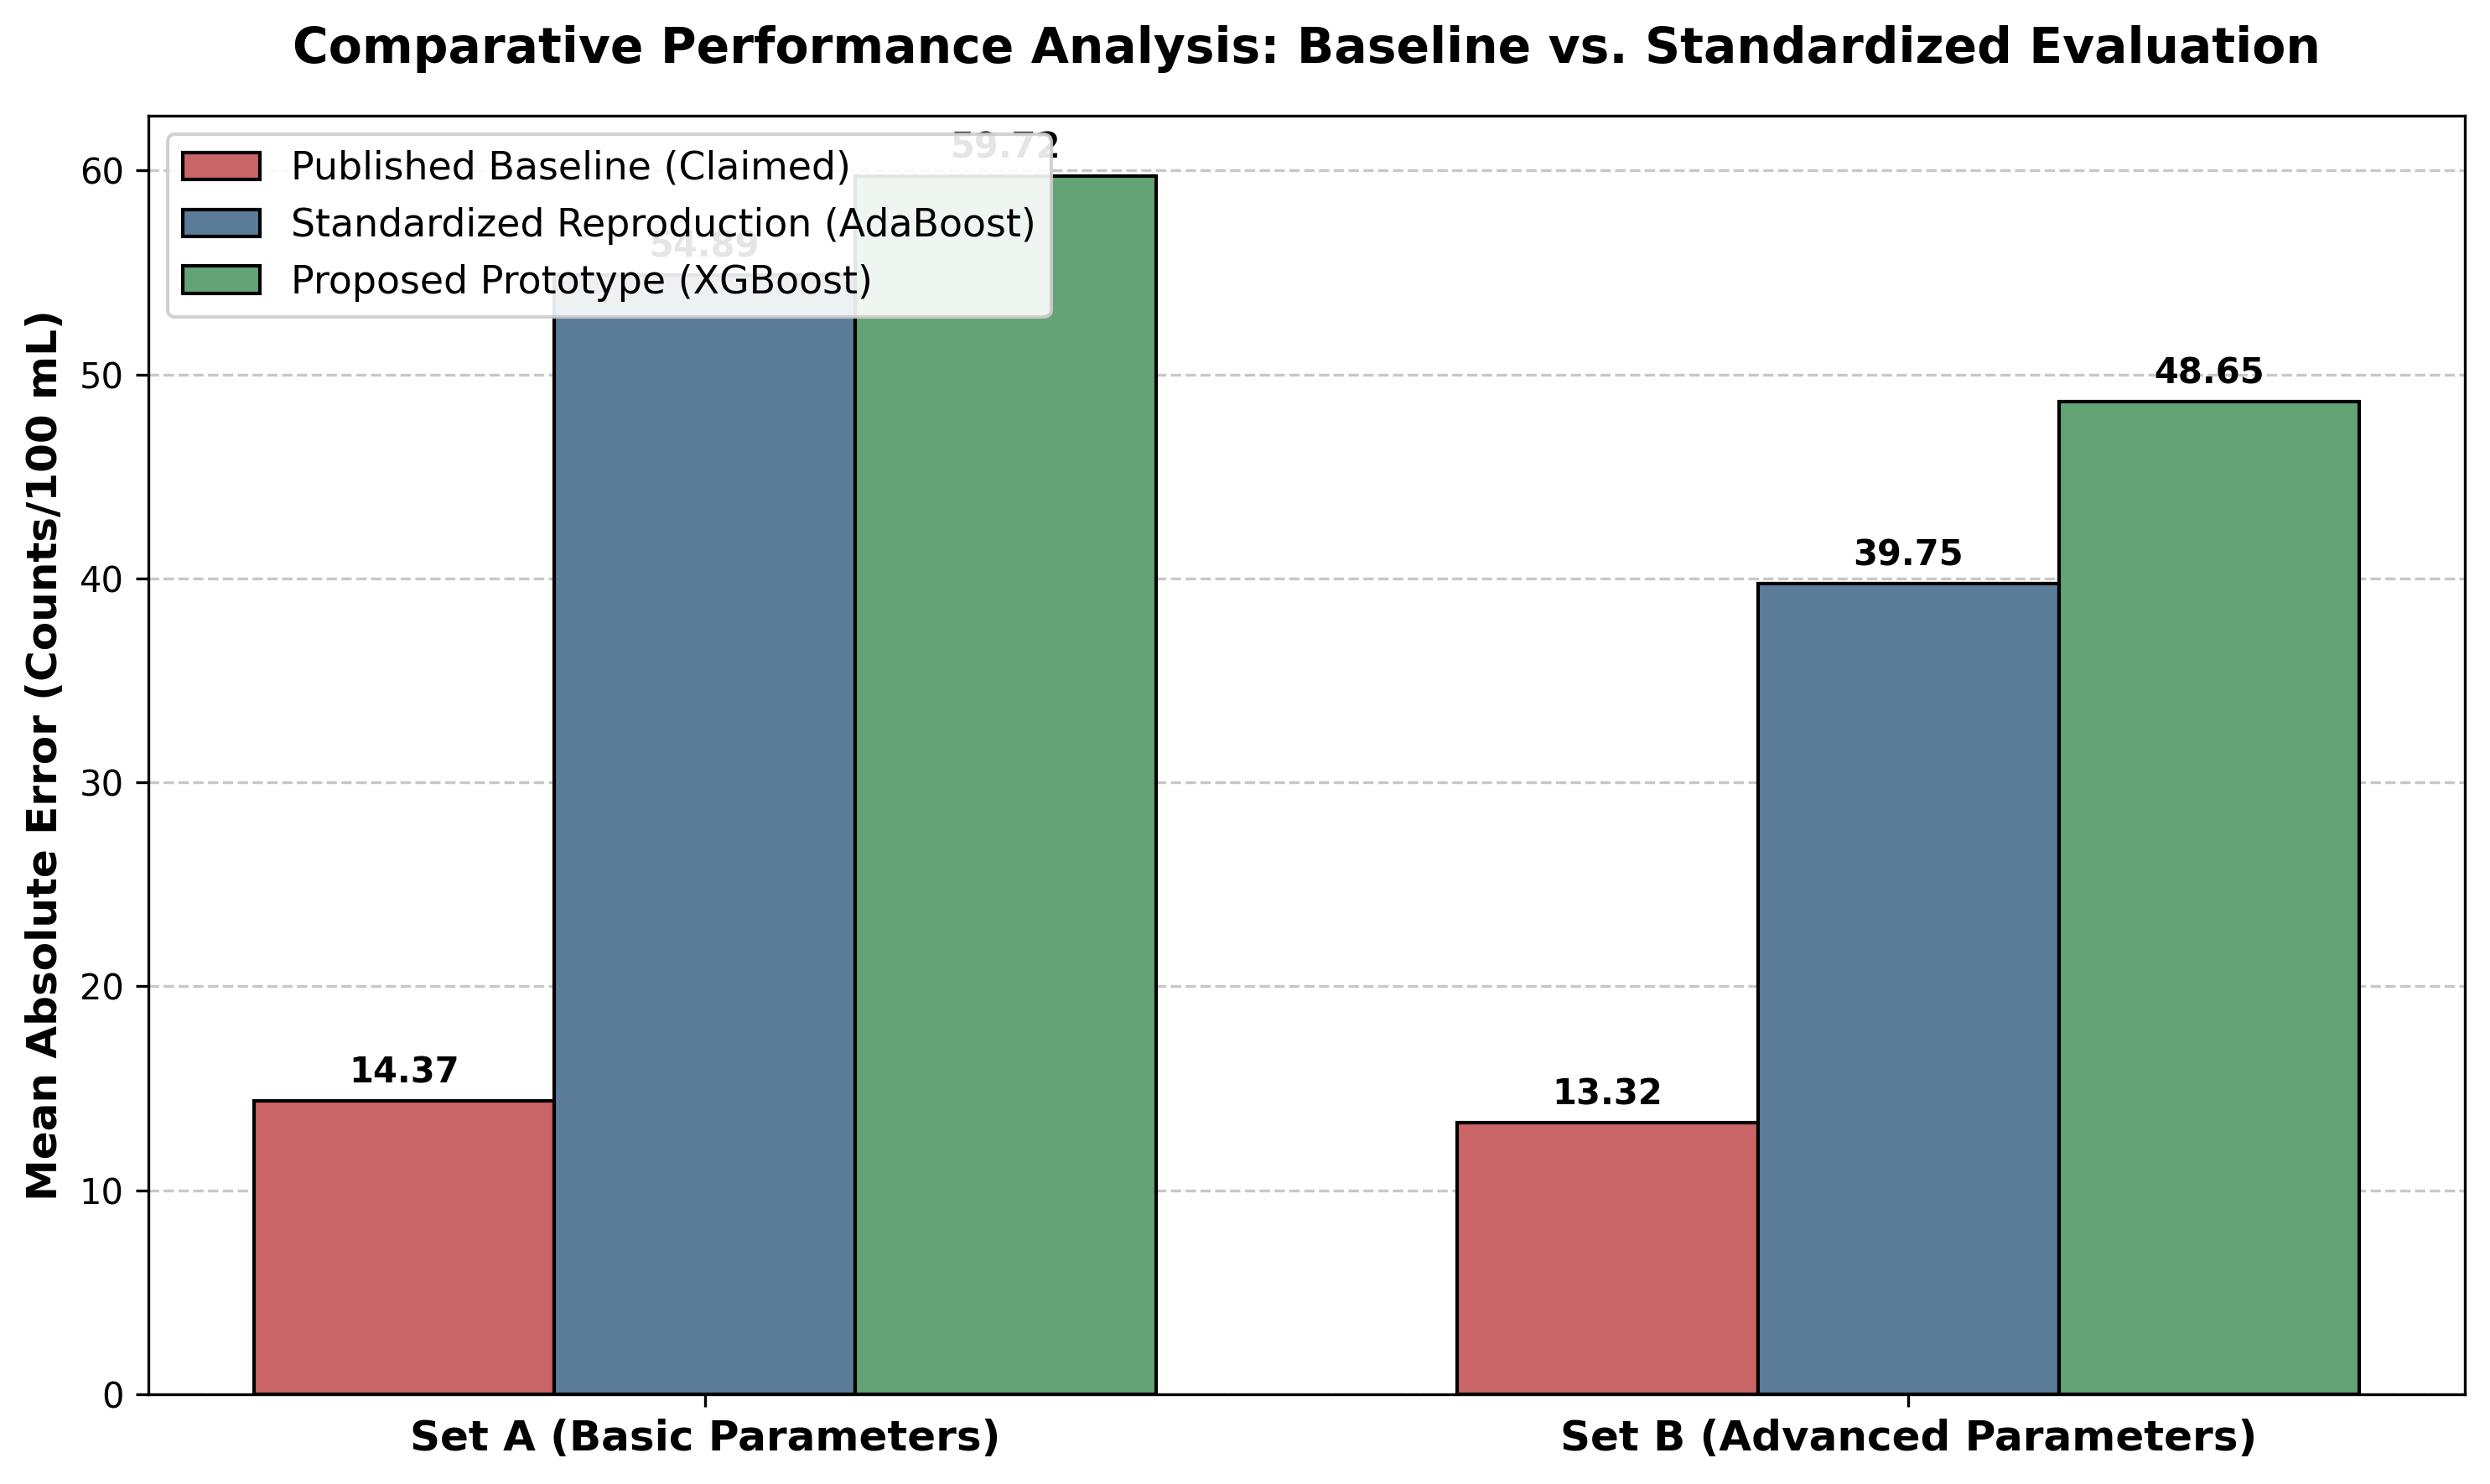

In [96]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# FINALIZED THESIS DATA
# ==========================================

# SET A (Basic Parameters)
set_A_claimed = 14.37        # Baseline Published AdaBoost MAE
set_A_reproduced = 54.89     # Standardized AdaBoost Reproduction MAE
set_A_xgboost = 59.72        # Optimized XGBoost Prototype MAE

# SET B (Advanced Parameters)
set_B_claimed = 13.32        # Baseline Published AdaBoost MAE
set_B_reproduced = 39.75     # Standardized AdaBoost Reproduction MAE
set_B_xgboost = 48.65        # Optimized XGBoost Prototype MAE

# ==========================================
# GRAPH GENERATION
# ==========================================

labels = ['Set A (Basic Parameters)', 'Set B (Advanced Parameters)']
claimed_scores = [set_A_claimed, set_B_claimed]
reproduced_scores = [set_A_reproduced, set_B_reproduced]
xgboost_scores = [set_A_xgboost, set_B_xgboost]

x = np.arange(len(labels))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# color palette (muted red, slate blue, forest green)
rects1 = ax.bar(x - width, claimed_scores, width, label='Published Baseline (Claimed)', color='#c96467', edgecolor='black')
rects2 = ax.bar(x, reproduced_scores, width, label='Standardized Reproduction (AdaBoost)', color='#5b7c99', edgecolor='black')
rects3 = ax.bar(x + width, xgboost_scores, width, label='Proposed Prototype (XGBoost)', color='#63a375', edgecolor='black')

# Formatting
ax.set_ylabel('Mean Absolute Error (Counts/100 mL)', fontsize=12, fontweight='bold')
ax.set_title('Comparative Performance Analysis: Baseline vs. Standardized Evaluation', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)

# subtle grid
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

# data labels on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

# Adjust layout and Save
fig.tight_layout()
plt.savefig('professional_thesis_defense_graph.png', format='png', dpi=300)
plt.show()